# Segmentación de Clientes de un centro comercial

Tenemos un conjunto de datos con información de clientes. Estos clientes son de un centro comercial y necesitamos segmentarlos para proporcionar información útil y diferentes insights al equipo de marketing, de modo que puedan preparar campañas comerciales o adaptar productos a cada segmento de clientes específico. Esto suele ser fácil de hacer cuando tenemos datos sobre nuestros clientes, como la edad, el ingreso o el monto gastado y el tipo de productos que ya compraron.

Comencemos por echar un vistazo a nuestros datos y realizar la limpieza necesaria. Aunque sepamos que estos datos son simples y casi listos para usar.



##Problema a resolver
Eres dueño de un centro comercial y, a través de tarjetas de membresía, tienes algunos datos básicos sobre tus clientes, como el ID del cliente, edad, género, ingreso anual y puntuación de gasto.
La puntuación de gasto es algo que asignas al cliente en función de parámetros definidos como el comportamiento del cliente y los datos de compra.

Eres propietario del centro comercial y deseas comprender a los clientes, como quiénes pueden converger fácilmente (clientes objetivo), de modo que se pueda proporcionar sentido al equipo de marketing y planificar la estrategia en consecuencia.






## Importación de Librerías

In [1]:
# Uso General
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clusterización
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

# Visualización 3D
import plotly as py
import plotly.graph_objs as go

## Análisis de datos Exploratiorio (EDA)

In [3]:
#Conexión a Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Carga del data set en pandas
df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv", index_col="CustomerID")

#Sacamos 15 registros por pantalla para observar nuestros datos
df.head(15)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
6,Female,22,17,76
7,Female,35,18,6
8,Female,23,18,94
9,Male,64,19,3


In [5]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


Eliminamos la columna del género porque el algoritmo de K-Means únicamente funciona con variables cuantitativas.

In [7]:
df.drop(columns=['Gender'], inplace=True)

A continuación vamos a hacer un análisis de la distribución y de la escala de nuestras variables/características para ver si es necesario realizar alguna transformación de los datos. Recordad que el algorimto de agrupación K-Means es muy sensible tanto a los valores atípicos cómo a la diferencia de escala en las variables predictoras.

/tmp/ipython-input-2732350774.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"])


<Axes: xlabel='Age', ylabel='Density'>

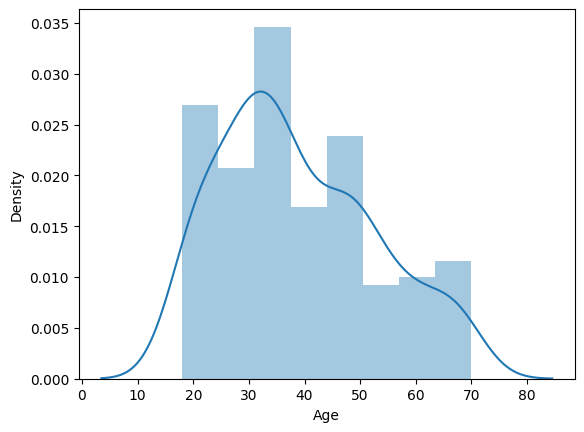

In [8]:
sns.distplot(df["Age"])

/tmp/ipython-input-2895917201.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Annual Income (k$)"])


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

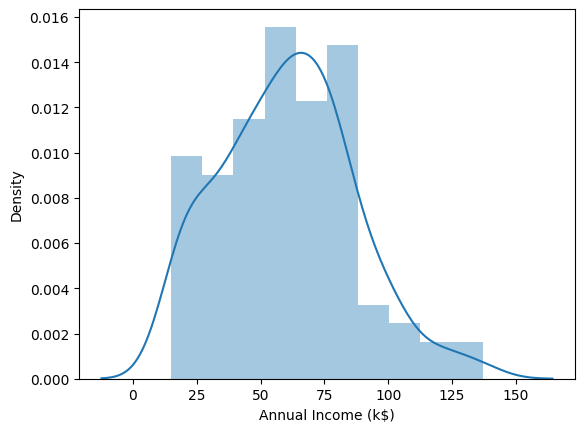

In [9]:
sns.distplot(df["Annual Income (k$)"])

/tmp/ipython-input-73916267.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Spending Score (1-100)"])


<Axes: xlabel='Spending Score (1-100)', ylabel='Density'>

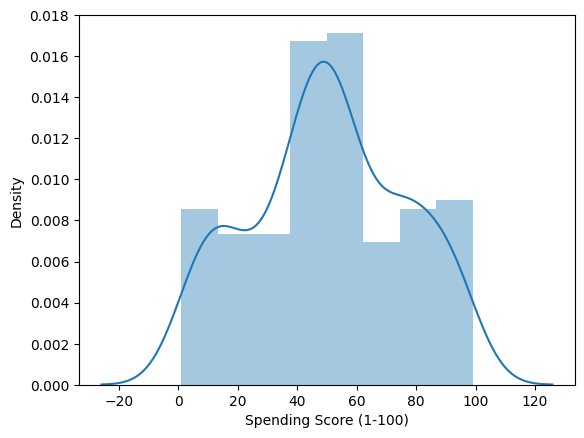

In [10]:
sns.distplot(df["Spending Score (1-100)"])

Tras observar las gráficas, observamos que las variables siguen distribuciones "similares" a la normal y no cuentan con valores atípicos. Las mayores densidades tampoco están agrupadas en los extremos. No es necesario estandarizar las escalas de las variables ya que son muy similares porque los datos están preparados para ello.

No obstante, estandarizar los datos es algo muy común en la aplicación de K-Means, por lo que añadimos aquí la documentación sobre la función [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) de SK-Learn.

**Ejercicio 1**: Realizar gráficas más detalladas (boxplot y similares) para estudiar las distribuaciones de las variables y el ruido/valores atípicos

## Segmentación de clientes con el ingreso anual y la puntuación de gasto

Empezamos la segmentación sólo teniendo en cuenta las dos variables más relevantes: Puntuación de gasto y salario anual. De momento descartaremos la variable edad y posteriormente realizaremos el mismo análisis para las tres variables en su conjunto.

In [11]:
df1 = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [12]:
df1.head(15)

,Annual Income (k$),Spending Score (1-100)
CustomerID,,
1,15,39
2,15,81
3,16,6
4,16,77
5,17,40
6,17,76
7,18,6
8,18,94
9,19,3


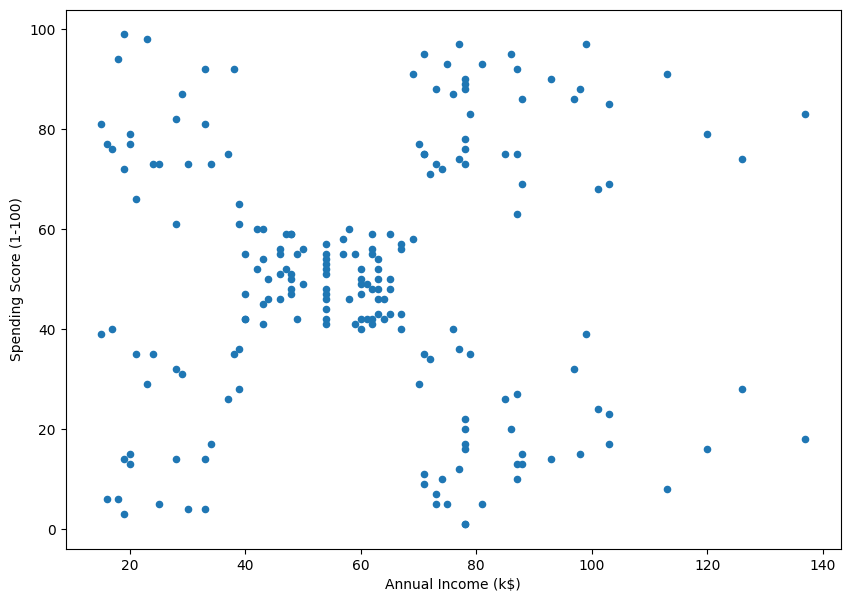

In [13]:
df1.plot(kind="scatter",
        x="Annual Income (k$)",
        y="Spending Score (1-100)",
        figsize=(10, 7))
plt.show()

Realizamos un Scatter Plot para ver la distribución de nuestros datos teniendo en cuenta las dos variables de interés. Estudiando la distribución podemos ver que es posible que existan 4,5 o incluso 6 clústeres diferenciados. La visualización de los datos debe ser una herramienta más dentro del criterio del analista de datos.

#### Método del codo para encontrar el número óptimo de clústers

En este caso emplearemos el método del codo visto en teoría para determinar el valor del hiperparámetro de K-Means, es decir, K. Realizaremos la ejecución del algoritmo para diferentes valores de K y elegiremos aquel para el cuál la suma de cuadrados intra-clúster se estabiliza.

**Partición inicial en K-Means**

Cómo hemos visto en teoría, los resultados de la agrupación de K-Means son muy sensibles a la partición incial escogida de los datos. Veamos las diferentes opciones de inicialización que nos ofrece la librería de SK-Learn:

*   Inicialización aleatoria ('random'): se seleccionan k centroides de manera aleatoria de entre los puntos de datos. Este es un método simple y comúnmente utilizado, pero puede dar lugar a agrupaciones subóptimas si los centroides iniciales no representan adecuadamente la distribución de los datos.

*   Inicialización K-means++ ('k-means++'): es una técnica de inicialización que selecciona k centroides de manera estratégica, eligiendo el primer centroide de forma aleatoria y luego seleccionando los centroides restantes basándose en la distancia respecto a los previamente elegidos. Este enfoque ayuda a evitar agrupamientos subóptimos y mejora la calidad de agrupamiento en comparación con la inicialización aleatoria en el algoritmo K-Means.

*   Inicialización manual (pasándole un array): en algunos casos, el usuario puede tener conocimiento previo sobre los datos y los clústeres esperados, de esta forma puede especificar manualmente los centroides iniciales.

* Es muy importante seleccionar el parámetro n_init entre 10 y 20 como valores. Este parámetro indica cuantas ejecuciones de K-Means se realizan, quedándose con la óptima. Un número alto asegura una convergencia mayor a la solución óptima.

* El parámetro random_state = 42 asegura que las semillas aleatorias de cada ejecución sean las mismas. No es necesario para garantizar la convergencia.

[Aquí](https://www.kdnuggets.com/2020/06/centroid-initialization-k-means-clustering.html) aportamos información más detallada sobre los tipos de inicialización.

In [42]:
sum_of_sqr_dist = {}

#Ponemos 1000 como máximo de iteraciones (de default son 300) y
for k in range(1, 10):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000, n_init= 20)
    km = km.fit(df1)
    sum_of_sqr_dist[k] = km.inertia_

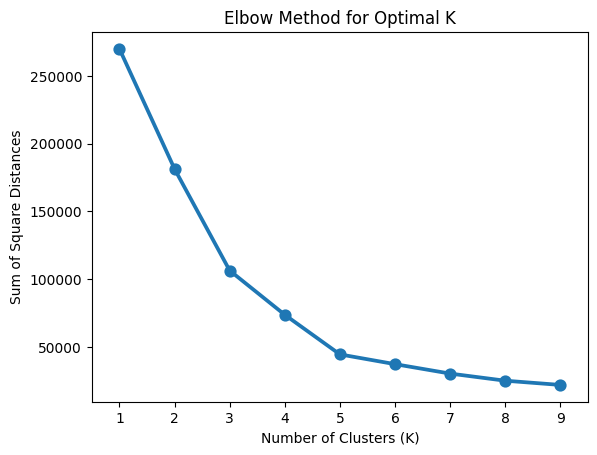

In [43]:
sns.pointplot(x=list(sum_of_sqr_dist.keys()), y=list(sum_of_sqr_dist.values()))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Square Distances")
plt.title("Elbow Method for Optimal K")
plt.show()

Observamos que el valor WSSK (varianza intra-clúster) se estabiliza sobre K=5, es decir, al aplicar más clústeres la varianza no se reduce en gran medida y no parece ser significativo tener más grupos diferentes. Como Data Scientits, es importante entender el problema e interpretar los datos. En este caso elegiremos K=5.

### K-Means Clustering

Seleccionamos k=5 y hacemos el KMeans clustering. El algoritmo es muy sensible a la inicialización de los clústeres y la existencia de outliers (esto no hay porque se ha comprobado con los gráficos de las distribuciones). Gracias a la inicialización 'k-means++', esto tampoco afectará a nuestro clustering.

In [44]:
Model = KMeans(n_clusters=5,
             init='k-means++',
             max_iter=1000, n_init= 20)
Model.fit(df1)

KMeans(max_iter=1000, n_clusters=5, n_init=20)

Mostramos por pantalla las agrupaciones realizadas sobre nuestro total de observaciones contenidas en el data set.

In [45]:
print("Labels", Model.labels_)

Labels [0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 1 0 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 4 3 1 3 4 3 4 3 1 3 4 3 4 3 4 3 4 3 1 3 4 3 4 3
 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]


Mostramos el valor y posición de los centroides correspondientes a los 5 clústers.

In [46]:
print("Centroids", Model.cluster_centers_)

Centroids [[26.30434783 20.91304348]
 [55.2962963  49.51851852]
 [25.72727273 79.36363636]
 [86.53846154 82.12820513]
 [88.2        17.11428571]]


In [47]:
centroids = Model.cluster_centers_

Vamos a añadir las agrupaciones realizadas como una nueva variable "Clúster" a nuestro propio data frame. De esta forma ya contaríamos con unos datos etiquetados (teniendo en cuenta la fiabilidad) con los que se podrían aplicar métodos de machine learning supervisados.

In [48]:
df1_cluster = df1.copy()
df1_cluster["Cluster"] = Model.fit_predict(df1)
df1_cluster.head()

,Annual Income (k$),Spending Score (1-100),Cluster
CustomerID,,,
1,15,39,4
2,15,81,3
3,16,6,4
4,16,77,3
5,17,40,4


### Visualización de clusters

Vamos a realizar un gráfico donde visualizar los diferentes clústeres agrupados por el método de K-Means. Añadiremos los centroides (vectores de media muestral de cada grupo) para su representación en el gráfico.

De esta manera podemos observar gráficamente si las agrupaciones realizadas son significativas.

In [49]:
Color = ['red', 'blue', 'black', 'gold', 'navy']
df1_cluster['Color'] = df1_cluster['Cluster'].map(lambda p:Color[p])

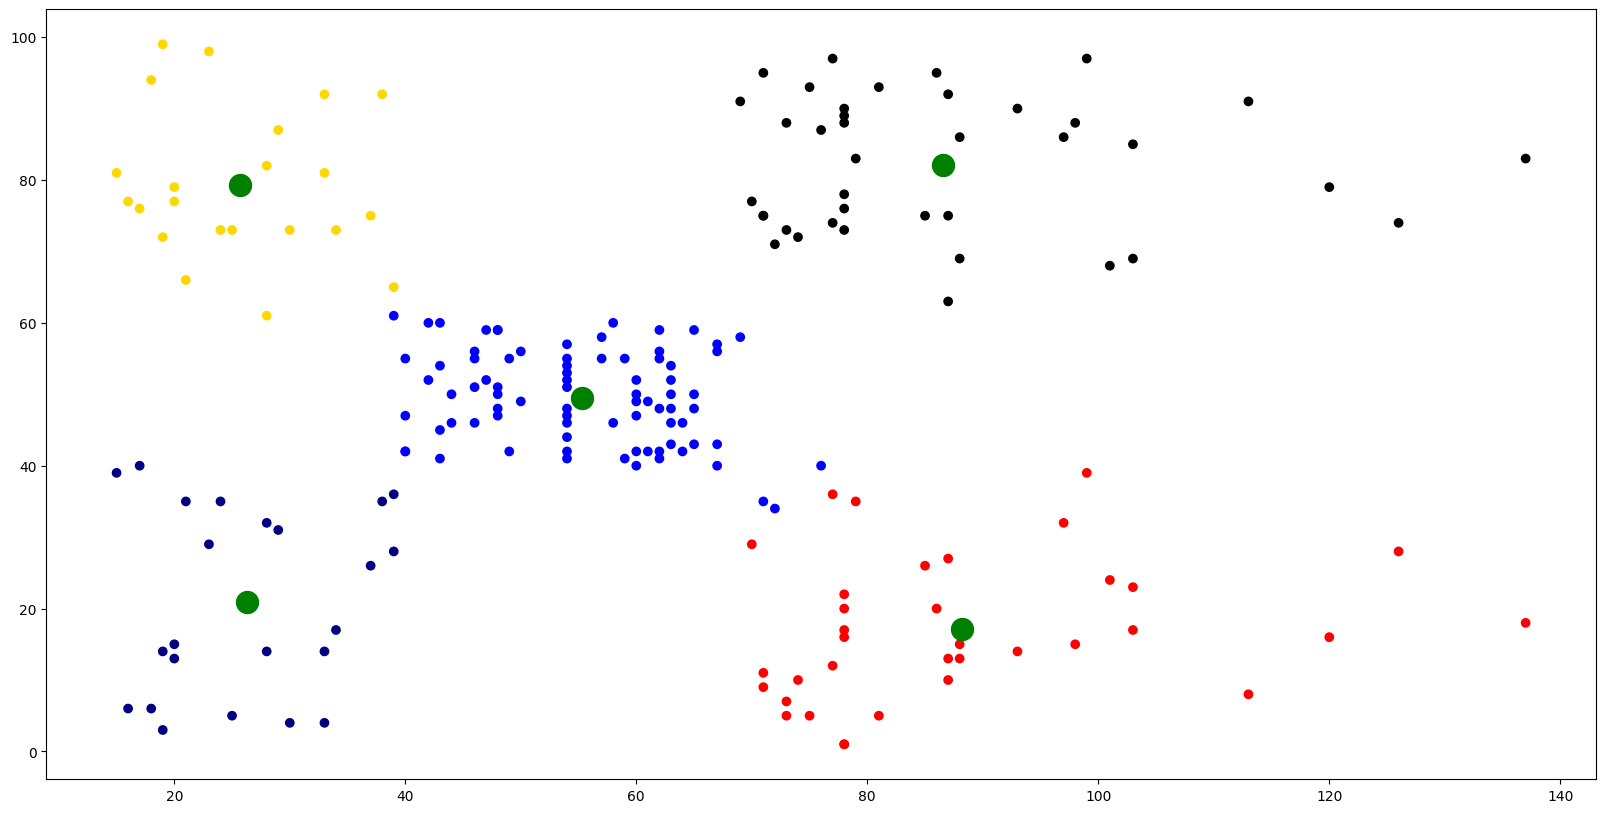

In [50]:
plt.figure(figsize=(20, 10))
plt.scatter(df1["Annual Income (k$)"],
           df1["Spending Score (1-100)"],
           c=df1_cluster["Color"])

plt.scatter(centroids[:, 0], centroids[:, 1], c='green', s=250)
plt.show()

### Evaluación con la métrica Silueta

La silueta (Silhouette) es una medida utilizada para evaluar la calidad de un agrupamiento (cluster) en análisis de clusters. Proporciona una indicación de qué tan bien separados están los grupos y qué tan similares son los puntos dentro de cada grupo.

Dicha métrica varia de -1 a 1. Un valor positivo y cercano a uno indica que las agrupaciones se han realizado correctamente. Lo contrario de manera análoga para el valor de -1. Vamos a calcular la silueta de nuestro modelo para comprobar la calidad del clustering llevado a cabo.

In [54]:
labels = Model.labels_

In [55]:
silhouette_score(df1, labels)

np.float64(0.553931997444648)

La silueta de nuestra segmentación es 0.55, un valor que indica que la agrupación ha sido bastante buena. Ahora nos hacemos la pergunta, ¿existirá un valor de K (número de clústers) para el cuál la silueta del modelo sea mayor?

In [60]:
silhouette = {}

for k in range(2,8):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000, n_init =20)
    km.fit(df1)
    silhouette[k] = silhouette_score(df1, km.labels_)

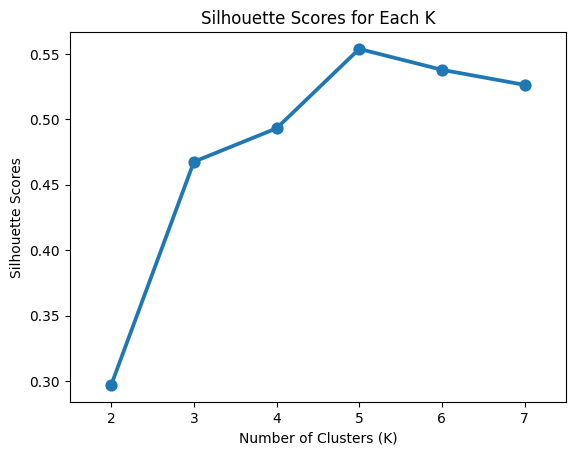

In [61]:
sns.pointplot(x=list(silhouette.keys()), y=list(silhouette.values()))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores for Each K")
plt.show()

Realizando este análisis, podemos conlcuir que el valor óptimo de K para nuestros datos agrupados con K-Means es 5.

### Evaluación con Gap Statistics

In [ ]:
n_clusters=5,
             init='k-means++',
             max_iter=1000, n_init= 20

In [62]:
def calculate_gap_statistic(data, refs=None, n_refs=10, max_k=10):
    """
    Calcula el Gap Statistic para el rango de clusters K = [1, max_k].

    Parámetros:
    - data: array numpy de los datos (normalizados)
    - refs: datos de referencia generados aleatoriamente (si es None, se generan internamente)
    - n_refs: número de conjuntos de referencia
    - max_k: máximo número de clusters a evaluar

    Devuelve:
    - gaps: lista con los valores Gap Statistic para cada valor de K
    - deviations: desviaciones estándar de las simulaciones
    """
    if refs is None:
        refs = np.random.uniform(low=np.min(data, axis=0), high=np.max(data, axis=0), size=(data.shape[0] * n_refs, data.shape[1]))

    gaps = []
    deviations = []

    for k in range(1, max_k + 1):
        # Ajuste del modelo KMeans en los datos reales
        kmeans = KMeans(n_clusters=k, init = 'k-means++', n_init =20)
        kmeans.fit(data)
        disp_real = np.mean(np.min(pairwise_distances(data, kmeans.cluster_centers_), axis=1))

        # Ajuste del modelo KMeans en los datos aleatorios
        disp_refs = []
        for i in range(n_refs):
            ref_subset = refs[i * data.shape[0]:(i + 1) * data.shape[0], :]
            kmeans.fit(ref_subset)
            disp_refs.append(np.mean(np.min(pairwise_distances(ref_subset, kmeans.cluster_centers_), axis=1)))

        # Gap Statistic y desviación estándar
        gap = np.log(np.mean(disp_refs)) - np.log(disp_real)
        sd_k = np.sqrt(np.mean((np.log(disp_refs) - np.log(np.mean(disp_refs))) ** 2))
        sk = sd_k * np.sqrt(1 + 1 / n_refs)  # Ajuste por el número de referencias

        gaps.append(gap)
        deviations.append(sk)

    return np.array(gaps), np.array(deviations)

Es el número de conjuntos de datos aleatorios que se generan para estimar la dispersión esperada bajo una distribución aleatoria.
Un mayor número de referencias mejora la precisión en la estimación de la dispersión esperada, pero también aumenta el tiempo de cálculo.


In [63]:
n_refs = 50
max_k = 15

In [66]:
gaps, deviations = calculate_gap_statistic(df1, n_refs=n_refs, max_k=max_k)

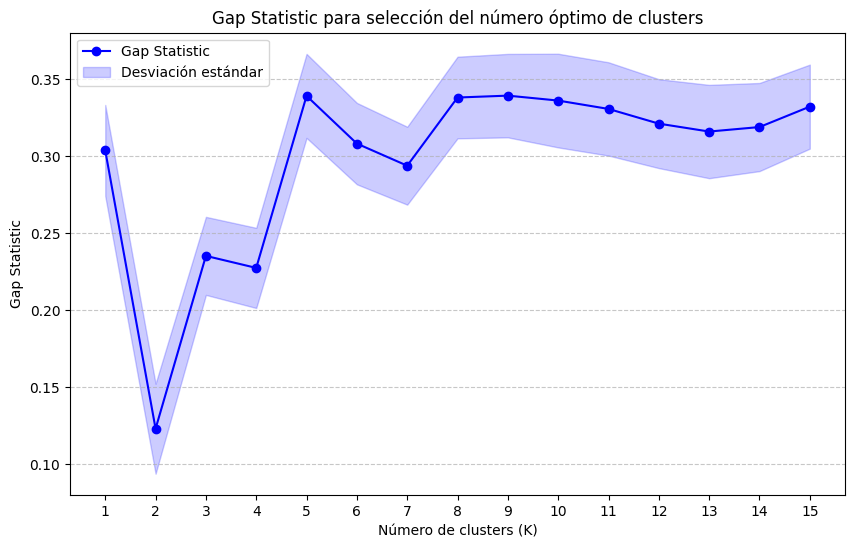

In [67]:
ks = np.arange(1, max_k + 1)
plt.figure(figsize=(10, 6))
plt.plot(ks, gaps, marker='o', linestyle='-', color='blue', label='Gap Statistic')
plt.fill_between(ks, gaps - deviations, gaps + deviations, color='blue', alpha=0.2, label='Desviación estándar')
plt.title('Gap Statistic para selección del número óptimo de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Gap Statistic')
plt.xticks(ks)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Segmentación de clientes con las 3 características

Vamos a realizar el análisis llevado a cabo en la sección anterior de manera análoga, pero esta vez contando también con la variable Edad, lo que añade mayor complejidad al data set.

In [68]:
df2= df.copy()

In [75]:
sum_of_sqr_dist = {}

for k in range(1, 10):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000, n_init =20)
    km = km.fit(df2)
    sum_of_sqr_dist[k] = km.inertia_

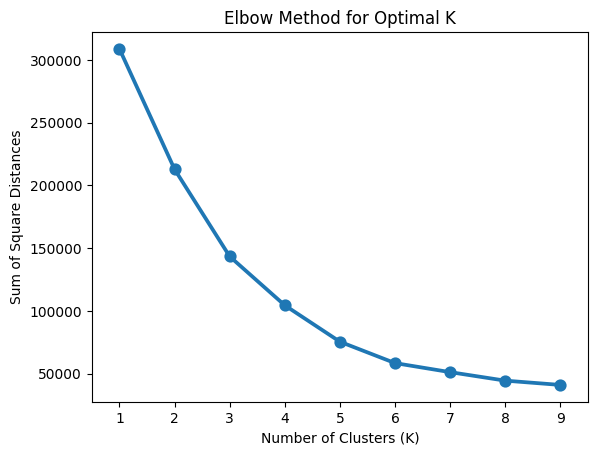

In [76]:
sns.pointplot(x=list(sum_of_sqr_dist.keys()), y=list(sum_of_sqr_dist.values()))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Square Distances")
plt.title("Elbow Method for Optimal K")
plt.show()

En este caso el codo de la curva no es muy pronunciado. Vamos a seleccionar k=6, pero deberemos realizar el análisis con la silueta para determinar que número de clústeres es el óptimo en este caso. La interpretación por parte del analista se torna crucial en estos casos.

In [77]:
Model2 = KMeans(n_clusters=6, init='k-means++', max_iter=1000, n_init =20)
Model2.fit(df2)

KMeans(max_iter=1000, n_clusters=6, n_init=20)

In [78]:
labels=Model2.labels_
silhouette_score(df2,labels)

np.float64(0.4523443947724053)

La silueta de nuestro nueva agrupación es de 0,45. Sigue siendo un valor de la métrica aceptable, pero ha bajado con respecto a la clusterización con dos variables. Tiene sentido, pues al añadir una nueva característica aumenta la dimensionalidad y la complejidad de nuestros datos y de la agrupación a realizar.

Vamos a añadir las agrupaciones realizadas como una nueva variable "Clúster" a nuestro propio data frame. De esta forma ya contaríamos con unos datos etiquetados (teniendo en cuenta la fiabilidad) con los que se podrían aplicar métodos de machine learning supervisados.

In [79]:
df2['Cluster'] = Model2.fit_predict(df2)
df2.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
CustomerID,,,,
1,19,15,39,2
2,21,15,81,4
3,20,16,6,2
4,23,16,77,4
5,31,17,40,2


**Visualización 3D**

Vamos a utilizar la libreria plotly para la visualización de nuestra clusterización en tres dimensiones. En este caso contamos con 6 grupos diferentes. Añadimos más [información detallada](https://plotly.com/python/graph-objects/) sobre esta librería para el lector interesado.

In [80]:
labels = Model2.labels_
centroids = Model2.cluster_centers_

In [81]:
df2

,Age,Annual Income (k$),Spending Score (1-100),Cluster
CustomerID,,,,
1,19,15,39,2
2,21,15,81,4
3,20,16,6,2
4,23,16,77,4
5,31,17,40,2
...,...,...,...,...
196,35,120,79,3
197,45,126,28,1
198,32,126,74,3


In [82]:
df2['labels'] = labels

trace = go.Scatter3d(
                    x = df2['Age'],
                    y = df2['Annual Income (k$)'],
                    z = df2['Spending Score (1-100)'],
                    mode = 'markers',
                    marker=dict(color=df2['labels'], size = 5, line=dict(color=df2['labels'], width=12), opacity=0.8)
                    )

data = [trace]
layout = go.Layout(
                    title='Clusters',
                    scene= dict(
                                xaxis = dict(title = 'Age'),
                                yaxis = dict(title = 'Annual Income (k$)'),
                                zaxis = dict(title = 'Spending Score (1-100)'))
                                )

fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)
plt.show()

Observando el gráfico en 3D (es completamente manipulable y ampliable) podemos observar que las agrupaciones son bastante representativas, existiendo claramente 6 clústers diferenciados. Es muy importante realizar estas visualizaciones para utilizar en nuestro análisis toda la información disponible.

Ante conjuntos de datos de mayor dimensionalidad (muchas variables predictoras) existen métodos para reducir dicha dimensionalidad y poder visualizar las agrupaciones. Añadimos un [artículo](https://365datascience.com/tutorials/python-tutorials/pca-k-means/) sobre una de las técnicas más populares para este propóstio, la PCA.

In [100]:
silhouette = {}

for k in range(2,15):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000, n_init =20)
    km.fit(df2)
    silhouette[k] = silhouette_score(df2, km.labels_)

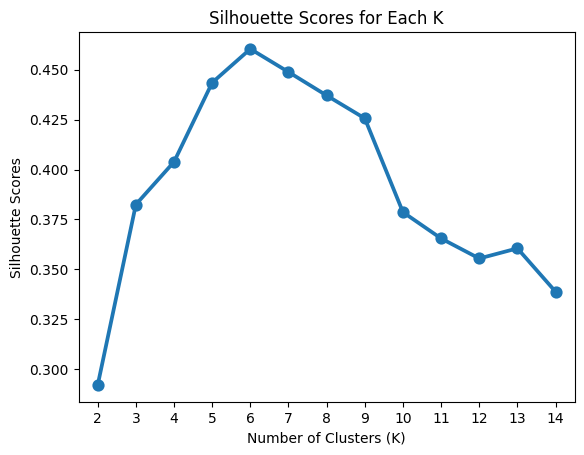

In [101]:
sns.pointplot(x=list(silhouette.keys()), y=list(silhouette.values()))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores for Each K")
plt.show()

Finalmente, realizamos el mismo análisis para comprobar que, efectivamente, el número de clústeres 6 era el óptimo para nuestro conjunto de datos en este caso.

In [106]:
gaps, deviations = calculate_gap_statistic(df2, n_refs=50, max_k=15)

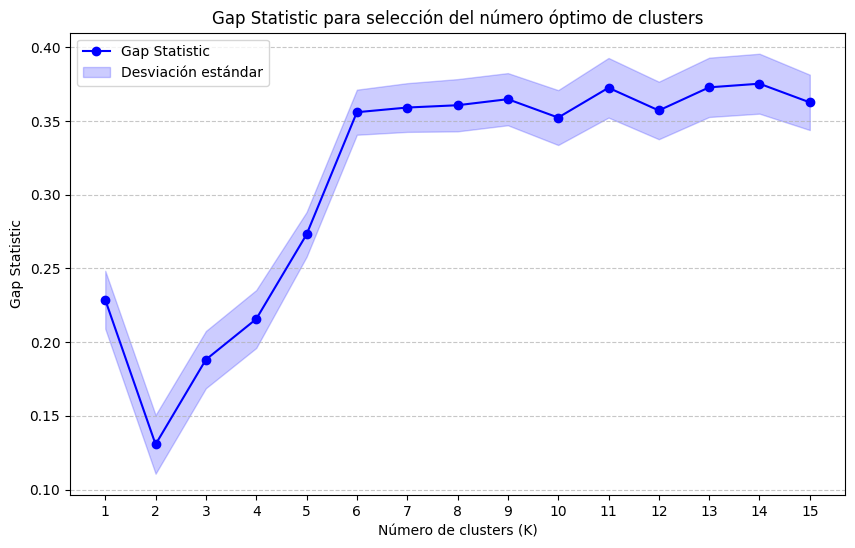

In [107]:
ks = np.arange(1, max_k + 1)
plt.figure(figsize=(10, 6))
plt.plot(ks, gaps, marker='o', linestyle='-', color='blue', label='Gap Statistic')
plt.fill_between(ks, gaps - deviations, gaps + deviations, color='blue', alpha=0.2, label='Desviación estándar')
plt.title('Gap Statistic para selección del número óptimo de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Gap Statistic')
plt.xticks(ks)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En este caso, el gap statistics nos indica que el primer máximo local sería K=9. Sin embargo, viendo el valor de la silueta, método del codo y la agrupación resultante en 3D, podemos concluir que K=6 es el mejor valor en este caso.

Por este motivo, es muy importante siempre realizar un análisis completo, con todas las métricas e información existente, para poder aplicar nuestro criterio como científicos de datos.

**Ejercicio 2:** Analizar en detalle cuál es el mejor valor de K. Ejecutar K Means con K = 7, ver la silueta y realizar un estudio visualizándolo gráficamente. Tener en cuenta no sobreajustar, la parsimonia y si realmente nos aporta valor considerar un clúster más.